<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/main/week11_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 게이트 순환 신경망(GRU)

출력게이트 :
출력 게이트(output galC)는 과거 정보와 현재 데이터를 시용하여 뉴런의 출력을 결정합니다. 이전
은닉 상태(hidden statc)와 t번째 입력을 고려해서 다음 은닉 상태를 계산합니다. 그리고 LSTM에서
는 이 은닉 상태가 그 시점에서의 출력이 됩니다.

## GRU 구조

GRU는 LSTM에서 시용하는 망각 게이트와 입력 게이트를 하나로 합친 것이며， 별도의 업데이트
게이트로 구성되어 있습니다.
하나의 게이트 컨트롤러(gate controller)가 망각 게이트와 입력 게이트를 모두 제어합니다. 게이트
컨트롤러가 1을 출력하면 망각 게이트는 열리고 입력 게이트는 닫히며 반대로 0을 출력하면 망
각 게이트는 닫히고 입력 게이트는 열립니다. 즉 이전 기억이 저장될 때마다 단계별 입력은 삭제
됩니다.
GRU는 출력 게이트가 없어 전체 상태 벡터가 매 단계마다 출력되며， 이전 상태의 어느 부분이 출력될지 제어하는 새로운 게이트 컨트롤러가 별도로 존재

* 망각 게이트: 과거 정보를 적당히 초기화하는 목적으로 시그모이드함수를 출력으로 이용해 (0,1)값을 은닉층에 곱함

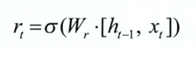

* 업데이트 게이트: 과거와 현재 정보의 최신화 비율을 결정하는 역할/
z는 현시점의 정보량 결정하고 1에서 뺀 값은 직전 시점의 은닉층 정보와 곱함

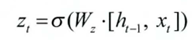

*후보군: 현시점의 정보에 대한 후보군을 계산합니다. 과거 은닉층의 정보를 그대로 이
용하지 않고 망각 게이트의 결과를 이용하여 후보군을 계산

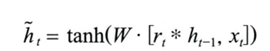

* 은닉층계산:
마지막으로 업데이트 게이트 결과와 후보군 결과를 결합하여 현시점의 은닉층을

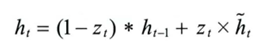

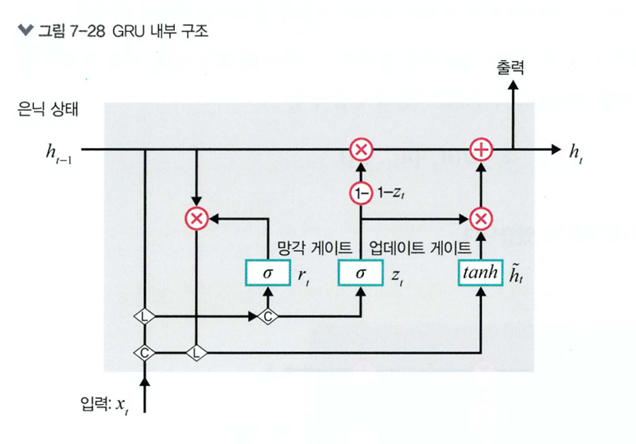

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cuda=True if torch.cuda.is_available() else False

Tensor=torch.cuda.FloatTensor if cuda else torch.FloatTensor
torch.manual_seed(125)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(125)

In [4]:
mnist_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(1.0,))
])

In [5]:
from torchvision.datasets import MNIST
download_root='/content/sample_data'
train_dataset=MNIST(download_root,transform=mnist_transform,train=True,
                    download=True)
valid_Dataset=MNIST(download_root,transform=mnist_transform,train=False,
                    download=True)
test_dataset=MNIST(download_root,transform=mnist_transform,train=False,
                   download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.31MB/s]


In [6]:
batch_size=64
train_loader=DataLoader(dataset=train_dataset,
                        batch_size=batch_size,
                        shuffle=True)
valid_loader=DataLoader(dataset=valid_Dataset,
                        batch_size=batch_size,
                        shuffle=True)
test_loader=DataLoader(dataset=test_dataset,
                       batch_size=batch_size,
                       shuffle=False)

In [9]:
batch_size=100
n_iters=6000
num_epochs=n_iters/(len(train_dataset)/batch_size)
num_epochs=int(num_epochs)

In [10]:
class GRUCell(nn.Module):
  def __init__(self,input_size,hidden_size,bias=True):
    super(GRUCell,self).__init__()
    self.input_size=input_size
    self.hidden_size=hidden_size
    self.bias=bias
    self.x2h=nn.Linear(input_size,3*hidden_size,bias=bias)
    self.h2h=nn.Linear(hidden_size,3*hidden_size,bias=bias)
    self.reset_parameters()
  def reset_parameters(self):
    std=1.0/math.sqrt(self.hidden_size)
    for w in self.parameters():
      for w in self.parameters():
        w.data.uniform_(-std,std)
  def forward(self,x,hidden):
    x=x.view(-1,x.size(1))
    gate_x=self.x2h(x)
    gate_h=self.h2h(hidden)
    gate_x=gate_x.squeeze()
    gate_h=gate_h.squeeze()
    i_r,i_i,i_n=gate_x.chunk(3,1)
    h_r,h_i,h_n=gate_h.chunk(3,1)
    resetgate=F.sigmoid(i_r+h_r)
    inputgate=F.sigmoid(i_i+h_i)
    newgate=F.tanh(i_n+resetgate*h_n)
    hy=newgate+inputgate*(hidden-newgate)
    return hy

In [23]:
from torch.distributed import is_available
class GRUModel(nn.Module):
  def __init__(self,num_classes,input_size,hidden_size,num_layers,seq_length):
    super(GRUModel,self).__init__()
    self.num_classes=num_classes
    self.hidden_size=hidden_size
    self.num_layers=num_layers
    self.input_size=input_size
    self.seq_length=seq_length
    self.gru=nn.GRU(input_size=input_size,hidden_size=hidden_size,
                    num_layers=num_layers,batch_first=True)
    self.fc_1=nn.Linear(hidden_size,128)
    self.fc=nn.Linear(128,num_classes)
    self.relu=nn.ReLU()
  def forward(self,x):
    h_0=Variable(torch.zeros(self.num_layers,x.size(0),self.hidden_size))
    output,(hn)=self.gru(x,(h_0))
    hn=hn.view(-1,self.hidden_size)
    out=self.relu(hn)
    out=self.fc_1(out)
    out=self.relu(out)
    out=self.fc(out)
    return out

In [12]:
num_epochs=1000
learning_rate=0.0001
input_size=5
hidden_size=2
num_layers=1
num_classes=1
model=GRUModel(num_classes,input_size,hidden_size,num_layers,X_train_tensors_f.shape[1]

In [13]:
seq_dim=28
loss_list=[]
iter=0
for epoch in range(num_epochs):
  for i, (images,labels)  in enumerate(train_loader):
    if torch.cuda.is_available():
      images=Variable(images.view(-1,seq_dim,input_dim).cuda())
      labels=Variable(labels.cuda())
    else:
      images=Variable(images.view(-1,seq_dim,input_dim))
      labels=Variable(labels)
    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    if torch.cuda.is_available():
      loss.cuda()
    loss.backward()
    optimizer.step()
    loss_list.append(loss.item())
    iter+=1
    if iter%500==0:
      correct=0
      total=0
      for images,labels in valid_loader:
        if torch.cuda.is_available():
          images=Variable(images.view(-1,seq_dim,input_dim).cuda())
        else:
          images=Variable(images.view(-1,seq_dim,input_dim))
        outputs=model(images)
        _,predicted=torch.max(outputs.data,1)
        total+=labels.size(0)
        if torch.cuda.is_available():
          correct+=(predicted.cpu()==labels.cpu()).sum()
        else:
          correct+=(predicted==labels).sum()
      accuracy=100*correct/total
      print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter,loss.item(),accuracy))


Iteration: 500. Loss: 2.3127262592315674. Accuracy: 10.279999732971191
Iteration: 1000. Loss: 2.2986857891082764. Accuracy: 10.279999732971191
Iteration: 1500. Loss: 2.3018503189086914. Accuracy: 11.350000381469727
Iteration: 2000. Loss: 2.301499128341675. Accuracy: 11.350000381469727
Iteration: 2500. Loss: 2.3073673248291016. Accuracy: 11.350000381469727
Iteration: 3000. Loss: 2.299954891204834. Accuracy: 11.350000381469727
Iteration: 3500. Loss: 2.3029165267944336. Accuracy: 11.350000381469727
Iteration: 4000. Loss: 2.2945384979248047. Accuracy: 11.350000381469727
Iteration: 4500. Loss: 2.303363800048828. Accuracy: 11.350000381469727
Iteration: 5000. Loss: 2.3059778213500977. Accuracy: 11.350000381469727
Iteration: 5500. Loss: 2.3190770149230957. Accuracy: 11.350000381469727
Iteration: 6000. Loss: 2.3062400817871094. Accuracy: 11.350000381469727
Iteration: 6500. Loss: 2.2947821617126465. Accuracy: 10.100000381469727
Iteration: 7000. Loss: 2.308363914489746. Accuracy: 11.3500003814697

In [14]:
def evaluate(model,val_iter):
  corrects,total,total_loss=0,0,0
  model.eval()
  for images,labels in val_iter:
    if torch.cuda.is_available():
      images=Variable(images.view(-1,seq_dim,input_dim).cuda())
      labels = labels.cuda()
    else:
      images=Variable(images.view(-1,seq_dim,input_dim).to(device))
      labels = labels.to(device)
    logit=model(images).to(device)
    loss=F.cross_entropy(logit,labels,reduction='sum')
    _,predicted=torch.max(logit.data,1)
    total+=labels.size(0)
    total_loss+=loss.item()
    corrects+=(predicted==labels).sum()
  avg_loss=total_loss/len(val_iter.dataset)
  avg_accuracy=corrects/total
  return avg_loss,avg_accuracy

In [15]:
test_loss,test_acc=evaluate(model,test_loader)
print('Test Loss: %5.2f | Test Accuracy: %5.2f'%(test_loss,test_acc))

Test Loss:  2.30 | Test Accuracy:  0.11


## GRU 계층 구현

In [16]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
device=torch.device('cuda:0' if torch.cuda.is_available( ) else 'cpu')

In [17]:
data=pd.read_csv('SBUX.csv')
print(data.dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [18]:
data['Date']=pd.to_datetime(data['Date'])
data.set_index('Date',inplace=True)
data['Volume']=data['Volume'].astype(float)

In [19]:
X=data.iloc[:,:-1]
y=data.iloc[:,5:6]
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

 MinMaxScaler()와 StandardScaler()를 사용하여 분산을 조정

In [20]:
ms=MinMaxScaler()
ss=StandardScaler()
X_ss=ss.fit_transform(X)
y_ms=ms.fit_transform(y)
X_train=X_ss[:200,:]
X_test=X_ss[200:,:]

y_train=y_ms[:200,:]
y_test=y_ms[200:,:]

print('Training Shape',X_train.shape,y_train.shape)
print('Testing Shape',X_test.shape,y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


In [21]:
X_train_tensors=Variable(torch.Tensor(X_train))
X_test_tensors=Variable(torch.Tensor(X_test))

y_train_tensors=Variable(torch.Tensor(y_train))
y_test_tensors=Variable(torch.Tensor(y_test))

X_train_tensors_f=torch.reshape(X_train_tensors,(X_train_tensors.shape[0],
                                                 1, X_train_tensors.shape[1]))
X_test_tensors_f=torch.reshape(X_test_tensors,(X_test_tensors.shape[0],
                                                 1, X_test_tensors.shape[1]))
print('Training Shape',X_train_tensors_f.shape,y_train_tensors.shape)
print('Testing Shape',X_test_tensors_f.shape,y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


In [24]:
class GRU(nn.Module):
  def __init__(self,num_classes,input_size,hidden_size,num_layers,seq_length):
    super(GRU,self).__init__()
    self.num_classes=num_classes
    self.num_layers=num_layers
    self.input_size=input_size
    self.hidden_size=hidden_size
    self.seq_length=seq_length

    self.gru=nn.GRU(input_size=input_size,hidden_size=hidden_size,
                      num_layers=num_layers,batch_first=True)
    self.fc_1=nn.Linear(hidden_size,128)
    self.fc=nn.Linear(128,num_classes)
    self.relu=nn.ReLU()
  def forward(self,x):
    h_0=Variable(torch.zeros(self.num_layers,x.size(0),self.hidden_size))
    c_0=Variable(torch.zeros(self.num_layers,x.size(0),self.hidden_size))
    output,(hn,cn)=self.gru(x,(h_0,c_0))
    hn=hn.view(-1,self.hidden_size)
    out=self.relu(hn)
    out=self.fc_1(out)
    out=self.relu(out)
    out=self.fc(out)
    return out


In [25]:
num_epochs=1000
learning_rate=0.0001
input_size=5
hidden_size=2
num_layers=1
num_classes=1
model=GRUModel(num_classes,input_size,hidden_size,num_layers,X_train_tensors_f.shape[1])
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [26]:
for epoch in range(num_epochs):
  outputs=model.forward(X_train_tensors_f)
  optimizer.zero_grad()
  loss=criterion(outputs,y_train_tensors)
  loss.backward()
  optimizer.step()
  if epoch%100==0:
    print('Epoch:%d, loss: %1.5f'%(epoch,loss.item()))

Epoch:0, loss: 0.24577
Epoch:100, loss: 0.07472
Epoch:200, loss: 0.03400
Epoch:300, loss: 0.02920
Epoch:400, loss: 0.02784
Epoch:500, loss: 0.02663
Epoch:600, loss: 0.02537
Epoch:700, loss: 0.02392
Epoch:800, loss: 0.02267
Epoch:900, loss: 0.02172


In [27]:
df_x_ss=ss.transform(data.iloc[:,:-1])
df_y_ms=ms.transform(data.iloc[:,-1:])
df_x_ss=Variable(torch.Tensor(df_x_ss))
df_y_ms=Variable(torch.Tensor(df_y_ms))
df_x_ss=torch.reshape(df_x_ss,(df_x_ss.shape[0],1,df_x_ss.shape[1]))

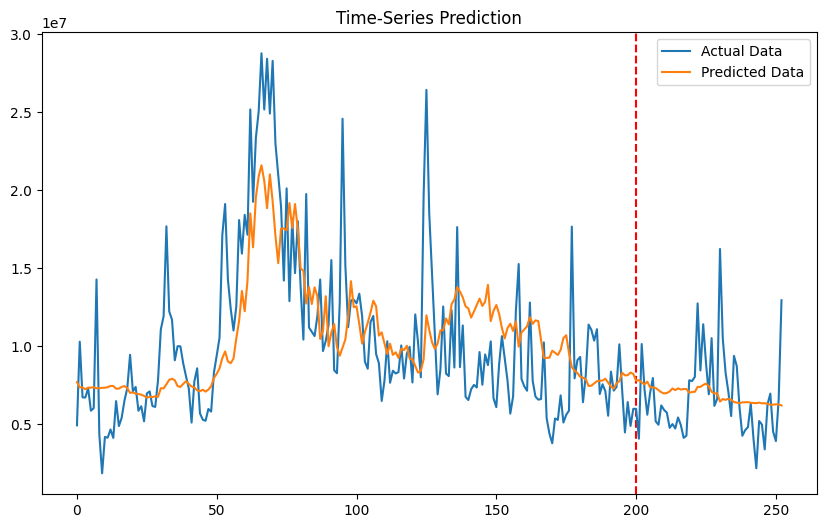

In [28]:
train_predict=model(df_x_ss)
predicted=train_predict.data.numpy()
label_y=df_y_ms.data.numpy()

predicted=ms.inverse_transform(predicted)
label_y=ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200,c='r',linestyle='--')
plt.plot(label_y,label='Actual Data')
plt.plot(predicted,label='Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()

# 7.7 양방향 RNN

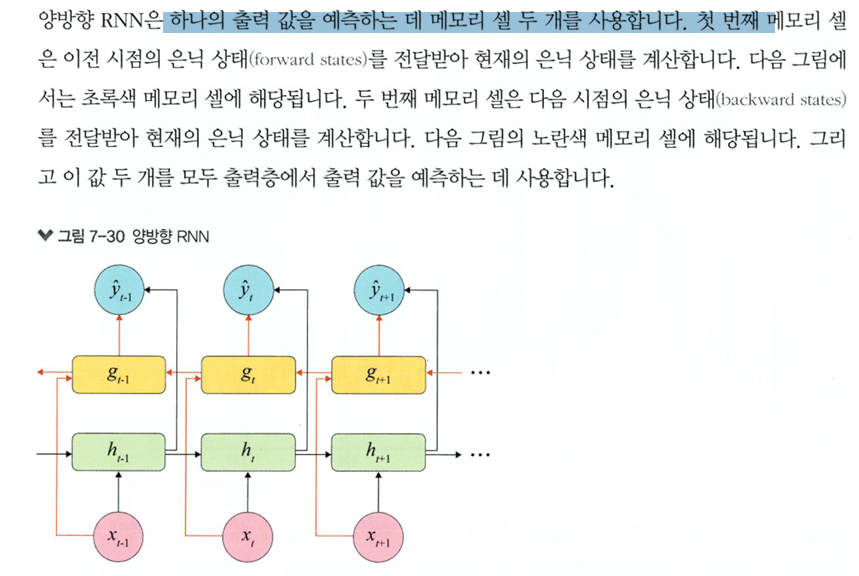

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
device=torch.device('cuda:0' if torch.cuda.is_available( ) else 'cpu')
data=pd.read_csv('SBUX.csv')
print(data.dtypes)
data['Date']=pd.to_datetime(data['Date'])
data.set_index('Date',inplace=True)
data['Volume']=data['Volume'].astype(float)
X=data.iloc[:,:-1]
y=data.iloc[:,5:6]
ms=MinMaxScaler()
ss=StandardScaler()
X_ss=ss.fit_transform(X)
y_ms=ms.fit_transform(y)
X_train=X_ss[:200,:]
X_test=X_ss[200:,:]

y_train=y_ms[:200,:]
y_test=y_ms[200:,:]
X_train_tensors=Variable(torch.Tensor(X_train))
X_test_tensors=Variable(torch.Tensor(X_test))

y_train_tensors=Variable(torch.Tensor(y_train))
y_test_tensors=Variable(torch.Tensor(y_test))

X_train_tensors_f=torch.reshape(X_train_tensors,(X_train_tensors.shape[0],
                                                 1, X_train_tensors.shape[1]))
X_test_tensors_f=torch.reshape(X_test_tensors,(X_test_tensors.shape[0],
                                                 1, X_test_tensors.shape[1]))
print('Training Shape',X_train_tensors_f.shape,y_train_tensors.shape)
print('Testing Shape',X_test_tensors_f.shape,y_test_tensors.shape)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object
Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


In [8]:
class biLSTM(nn.Module):
  def __init__(self,num_classes,input_size,hidden_size,num_layers,seq_length):
    super(biLSTM,self).__init__()
    self.num_classes=num_classes
    self.num_layers=num_layers
    self.input_size=input_size
    self.hidden_size=hidden_size
    self.seq_length=seq_length
    self.lstm=nn.LSTM(input_size=input_size,hidden_size=hidden_size,
                         num_layers=num_layers,bidirectional=True,batch_first=True)
    self.fc=nn.Linear(hidden_size*2,num_classes)
    self.relu=nn.ReLU()
  def forward(self,x):
    h_0=Variable(torch.zeros(self.num_layers*2,x.size(0),self.hidden_size)).to(x.device)
    c_0=Variable(torch.zeros(self.num_layers*2,x.size(0),self.hidden_size)).to(x.device)
    out,_=self.lstm(x,(h_0,c_0))
    out=self.fc(out[:,-1,:])
    out=self.relu(out)
    return out

In [9]:
num_epochs=1000
learning_rate=0.0001
input_size=5
hidden_size=2
num_layers=1
num_classes=1
model=biLSTM(num_classes,input_size,hidden_size,num_layers,X_train_tensors_f.shape[1])
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
for epoch in range(num_epochs):
  outputs=model.forward(X_train_tensors_f)
  optimizer.zero_grad()
  loss=criterion(outputs,y_train_tensors)
  loss.backward()
  optimizer.step()
  if epoch%100==0:
    print('Epoch:%d, loss: %1.5f'%(epoch,loss.item()))

Epoch:0, loss: 0.04429
Epoch:100, loss: 0.03940
Epoch:200, loss: 0.03533
Epoch:300, loss: 0.03194
Epoch:400, loss: 0.02913
Epoch:500, loss: 0.02688
Epoch:600, loss: 0.02514
Epoch:700, loss: 0.02383
Epoch:800, loss: 0.02284
Epoch:900, loss: 0.02203


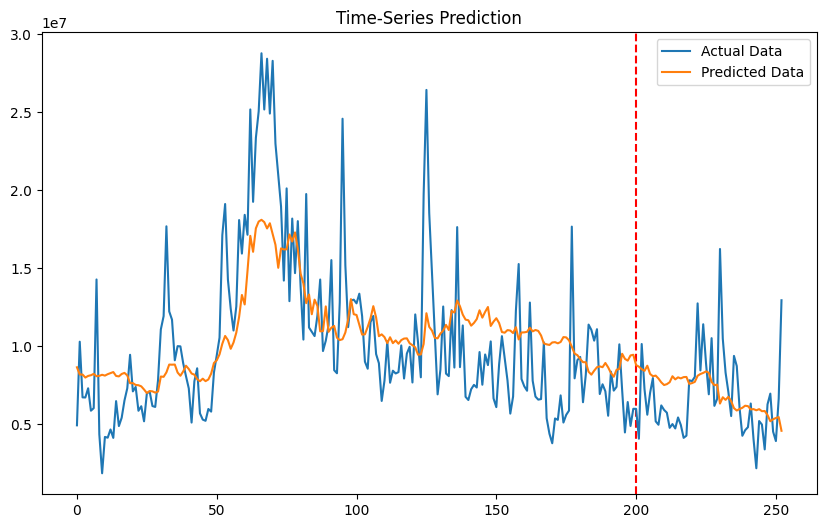

In [10]:
df_x_ss=ss.transform(data.iloc[:,:-1])
df_y_ms=ms.transform(data.iloc[:,-1:])
df_x_ss=Variable(torch.Tensor(df_x_ss))
df_y_ms=Variable(torch.Tensor(df_y_ms))
df_x_ss=torch.reshape(df_x_ss,(df_x_ss.shape[0],1,df_x_ss.shape[1]))
train_predict=model(df_x_ss)
predicted=train_predict.data.numpy()
label_y=df_y_ms.data.numpy()

predicted=ms.inverse_transform(predicted)
label_y=ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200,c='r',linestyle='--')
plt.plot(label_y,label='Actual Data')
plt.plot(predicted,label='Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()